# Workstream C: Business

Two files and three numbers. The deck is built in Canva; this notebook produces what
goes into it.

| Output | What it is |
|---|---|
| `out/swan_mailer_top500.csv` | the 500 customers to mail |
| `out/swan_churn_risk_all.csv` | churn risk for every remaining customer |
| Section 5 | which sign-up metric to incentivise at $2.50 |
| Section 6 | what the mailer costs and what it has to return |
| Section 7 | how to tell next quarter whether it worked |

Sections 1 to 4 build the deliverables. Sections 5 to 7 produce the figures the
presentation quotes.

## 1 · Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Path("out").mkdir(exist_ok=True)

# Swan brand palette. Navy is sampled from the logo wordmark; teal, coral and grey
# stay as the agreed data colours. Charts sit on the same paper as the slides so
# they drop into Canva without a white box around them.
navy, slate, paper, rule = "#163e67", "#55697c", "#f7f9fb", "#dce3ea"
teal, coral, grey = "#136e78", "#d1495b", "#9aa5a8"

plt.rcParams.update({
    "font.size": 11,
    "savefig.dpi": 200,                 # 2x for the deck
    "savefig.bbox": "tight",
    "figure.facecolor": paper,
    "axes.facecolor": paper,
    "savefig.facecolor": paper,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": rule,
    "axes.labelcolor": slate,
    "xtick.color": slate,
    "ytick.color": navy,
    "text.color": navy,
    "axes.grid": True,
    "grid.color": rule,
    "axes.axisbelow": True,
})

In [2]:
# The workbook sits either beside this notebook or one level up, depending on
# whether you are running from the repo folder or a working copy.
NAME = "Swan Consulting 1 - Project Data.xlsx"
CANDIDATES = [Path("data") / NAME, Path(NAME), Path("..") / NAME]
PATH = next(c for c in CANDIDATES if c.exists())
print(f"reading {PATH}")

df = pd.read_excel(PATH, sheet_name="Telco_Churn")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce").fillna(0)
df = df.drop(columns=["Count", "Country", "State", "Churn Label"])

df["is_echeck"] = (df["Payment Method"] == "Electronic check").astype(int)
df["is_month_to_month"] = (df["Contract"] == "Month-to-month").astype(int)
df["tenure_band"] = pd.cut(df["Tenure Months"], [-1, 6, 12, 24, 48, 72],
                           labels=["0-6", "7-12", "13-24", "25-48", "49-72"])

N = len(df)
BASE = df["Churn Value"].mean()
print(f"{N:,} customers, baseline churn {BASE:.1%}")

reading data\Swan Consulting 1 - Project Data.xlsx


7,043 customers, baseline churn 26.5%


## 2 · Churn scores from B

B delivers one file, `churn_scores.csv`, with all 7,043 rows and two columns:

```
CustomerID,churn_probability
3668-QPYBK,0.7312
9237-HQITU,0.6188
```

Three requirements, in order of how badly they break things:

1. **Out-of-fold.** Every row scored by a fold that did not train on it. A model scoring
   its own training data gives inflated probabilities and a top 500 that is partly
   memorised. This is the one that silently ruins the deliverable.
2. **Calibrated.** A customer scored 0.7 should churn about 70% of the time. The service
   team reads deliverable 2 as a risk number, so it has to mean what it says. Check with a
   reliability curve and Brier score, not AUC, which is unchanged by calibration.
3. **All 7,043 rows, CustomerID untouched**, no index column.

In [3]:
# Required, with no fallback on purpose. A placeholder here would quietly produce
# two client-facing CSVs built on invented numbers.
CANDIDATES = [Path("churn_scores.csv"), Path("data/churn_scores.csv"),
              Path("../churn_scores.csv")]
SCORES = next((c for c in CANDIDATES if c.exists()), None)
if SCORES is None:
    raise FileNotFoundError(
        "churn_scores.csv not found. Run B - logistic_regression.ipynb and export "
        "oof_proba alongside df_clean['CustomerID'] before running this notebook.")

scores = pd.read_csv(SCORES)
print(f"scores from {SCORES}: {len(scores):,} rows")

scores from churn_scores.csv: 7,043 rows


In [4]:
scored = df.merge(scores, on="CustomerID", how="left")

assert len(scored) == N, "row count changed on merge"
assert scored["CustomerID"].is_unique, "duplicate CustomerIDs"
assert scored["churn_probability"].notna().all(), "some customers have no score"
assert scored["churn_probability"].between(0, 1).all(), "probabilities outside 0 to 1"

scored = scored.sort_values("churn_probability", ascending=False).reset_index(drop=True)
scored["rank"] = scored.index + 1
print("scores validated")

In [5]:
BANDS = [("Critical", 0.60), ("High", 0.40), ("Medium", 0.20), ("Low", 0.00)]

def band(p):
    for name, floor in BANDS:
        if p >= floor:
            return name

scored["risk_band"] = scored["churn_probability"].apply(band)

check = scored.groupby("risk_band")["Churn Value"].agg(n="size", observed_churn="mean")
check.reindex([b[0] for b in BANDS])

,n,observed_churn
risk_band,,
Critical,1056,0.735795
High,1012,0.495059
Medium,1229,0.287225
Low,3746,0.063534


The observed churn rate in each band should land inside that band's range. That is what
calibration buys. Every band's observed churn should sit inside its own range.

Ties matter too. A model that gives many customers the same probability cannot order them,
so the cut between rank 500 and 501 becomes arbitrary.

In [6]:
print(f"distinct probabilities: {scored['churn_probability'].nunique():,} across {N:,} customers")
edge = scored["churn_probability"].iloc[499]
tied = (scored["churn_probability"] == edge).sum()
print(f"probability at rank 500: {edge:.4f}")
print(f"customers sharing it   : {tied:,}")
if tied > 1:
    print("  -> the 500/501 cut falls inside a tie, so the list is partly arbitrary")

distinct probabilities: 3,912 across 7,043 customers
probability at rank 500: 0.7405
customers sharing it   : 2
  -> the 500/501 cut falls inside a tie, so the list is partly arbitrary


## 3 · Deliverable 1, the 500 mailers

Ranked highest risk first. The extra columns are there so the retention team can act on a
row without going back to the database.

In [7]:
COLS = ["rank", "CustomerID", "churn_probability", "risk_band",
        "Contract", "Tenure Months", "Monthly Charges", "Payment Method"]

mailer = scored.head(500)[COLS].copy()
mailer["churn_probability"] = mailer["churn_probability"].round(4)
mailer["Monthly Charges"] = mailer["Monthly Charges"].round(2)

assert len(mailer) == 500
assert mailer["CustomerID"].is_unique
assert mailer["rank"].tolist() == list(range(1, 501))

mailer.to_csv("out/swan_mailer_top500.csv", index=False)
print("wrote out/swan_mailer_top500.csv")
mailer.head()

wrote out/swan_mailer_top500.csv


,rank,CustomerID,churn_probability,risk_band,Contract,Tenure Months,Monthly Charges,Payment Method
0,1,5178-LMXOP,0.9511,Critical,Month-to-month,1,95.10,Electronic check
1,2,7216-EWTRS,0.9475,Critical,Month-to-month,1,100.80,Electronic check
2,3,7181-BQYBV,0.9305,Critical,Month-to-month,1,102.45,Electronic check
3,4,4826-XTSOH,0.9304,Critical,Month-to-month,1,86.05,Electronic check
4,5,9497-QCMMS,0.9293,Critical,Month-to-month,1,93.55,Electronic check


In [8]:
# Who are they? This is the profile the presentation quotes.
top = scored.head(500)
print(f"precision@500 : {top['Churn Value'].mean():.1%}  "
      f"({int(top['Churn Value'].sum())} of 500 actually churned)")
print(f"benchmark     : 63.9% from the three-field rule in the EDA notebook")
print()
print(f"average tenure          {top['Tenure Months'].mean():.0f} months")
print(f"average monthly charge  ${top['Monthly Charges'].mean():.2f}")
print(f"monthly revenue at risk ${top['Monthly Charges'].sum():,.0f}")
print()
print("contract mix (%):")
print((top["Contract"].value_counts(normalize=True) * 100).round(1).to_string())
print("\npayment mix (%):")
print((top["Payment Method"].value_counts(normalize=True) * 100).round(1).to_string())

precision@500 : 83.4%  (417 of 500 actually churned)
benchmark     : 63.9% from the three-field rule in the EDA notebook

average tenure          3 months
average monthly charge  $79.78
monthly revenue at risk $39,889

contract mix (%):
Contract
Month-to-month    100.0

payment mix (%):
Payment Method
Electronic check             84.6
Mailed check                  7.6
Bank transfer (automatic)     4.6
Credit card (automatic)       3.2


## 4 · Deliverable 2, risk for the remaining customers

The brief asks for the churn likelihood of "all of our remaining customers", so the 500
already being mailed are excluded. The flag is kept so the two files can be recombined
without guessing.

In [9]:
rest = scored.iloc[500:][["CustomerID", "churn_probability", "risk_band"]].copy()
rest["churn_probability"] = rest["churn_probability"].round(4)
rest["in_mailer_list"] = 0

assert len(rest) == N - 500
assert rest["CustomerID"].is_unique
assert not set(rest["CustomerID"]) & set(mailer["CustomerID"]), "customer in both files"

rest.to_csv("out/swan_churn_risk_all.csv", index=False)
print(f"wrote out/swan_churn_risk_all.csv, {len(rest):,} rows")
rest["risk_band"].value_counts().reindex([b[0] for b in BANDS])

wrote out/swan_churn_risk_all.csv, 6,543 rows


risk_band
Critical     556
High        1012
Medium      1229
Low         3746
Name: count, dtype: int64

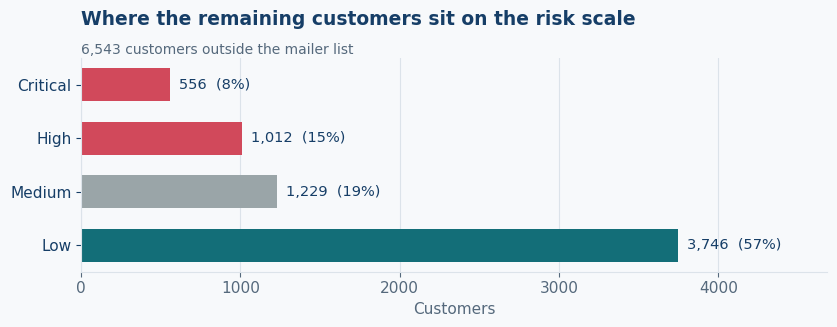

In [10]:
counts = rest["risk_band"].value_counts().reindex([b[0] for b in BANDS])[::-1]
colours = [coral, coral, grey, teal][::-1]

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.barh(counts.index, counts.values, color=colours, height=0.62)
for i, v in enumerate(counts.values):
    ax.text(v + counts.max() * 0.015, i, f"{v:,}  ({v/len(rest):.0%})",
            va="center", fontsize=10.5)

ax.set_xlim(0, counts.max() * 1.25)
ax.set_xlabel("Customers")
ax.grid(axis="y", visible=False)
ax.set_title("Where the remaining customers sit on the risk scale",
             loc="left", fontsize=13.5, fontweight="bold", pad=24)
ax.text(0, 1.02, f"{len(rest):,} customers outside the mailer list",
        transform=ax.transAxes, fontsize=10, color=slate)
fig.tight_layout()
fig.savefig("out/risk_band_distribution.png")

## 5 · Which sign-up metric to incentivise at $2.50

The client can pay $2.50 for every customer signed up to one metric, and wants to know
which. Six add-ons are candidates.

The comparison has to be fair. Each add-on column has a third level, `No internet service`,
and that is the same 1,526 customers every time. They did not decline the add-on, they were
never able to buy it. Including them measures the internet split rather than the add-on, so
this section uses only customers who could actually buy one.

In [11]:
ADDONS = ["Online Security", "Tech Support", "Online Backup",
          "Device Protection", "Streaming TV", "Streaming Movies"]

net = df[df["Internet Service"] != "No"]
print(f"could buy an add-on : {len(net):,}  (churn {net['Churn Value'].mean():.1%})")
print(f"excluded, no internet: {N - len(net):,}  "
      f"(churn {df[df['Internet Service'] == 'No']['Churn Value'].mean():.1%})")

In [12]:
rows = []
for a in ADDONS:
    g = net.groupby(a)["Churn Value"].agg(n="size", rate="mean")
    rows.append({"add_on": a,
                 "n_without": int(g.loc["No", "n"]), "churn_without": g.loc["No", "rate"],
                 "n_with": int(g.loc["Yes", "n"]), "churn_with": g.loc["Yes", "rate"],
                 "gap_pp": (g.loc["No", "rate"] - g.loc["Yes", "rate"]) * 100})

gaps = pd.DataFrame(rows).sort_values("gap_pp", ascending=False).reset_index(drop=True)
gaps.style.format({"churn_without": "{:.1%}", "churn_with": "{:.1%}",
                   "gap_pp": "{:.1f}", "n_without": "{:,}", "n_with": "{:,}"})

,add_on,n_without,churn_without,n_with,churn_with,gap_pp
0,Online Security,"3,498",41.8%,"2,019",14.6%,27.2
1,Tech Support,"3,473",41.6%,"2,044",15.2%,26.5
2,Online Backup,"3,088",39.9%,"2,429",21.5%,18.4
3,Device Protection,"3,095",39.1%,"2,422",22.5%,16.6
4,Streaming Movies,"2,785",33.7%,"2,732",29.9%,3.7
5,Streaming TV,"2,810",33.5%,"2,707",30.1%,3.5


In [13]:
t = gaps.sort_values("gap_pp")
y = np.arange(len(t))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
for i, r in enumerate(t.itertuples()):
    ax.plot([r.churn_with, r.churn_without], [i, i], color=rule, lw=3, zorder=1)
ax.scatter(t["churn_with"], y, s=110, color=teal, zorder=2, label="Holds the add-on")
ax.scatter(t["churn_without"], y, s=110, color=coral, zorder=2, label="Does not hold it")

for i, r in enumerate(t.itertuples()):
    ax.text(r.churn_without + 0.014, i, f"{r.gap_pp:.0f}pp gap", va="center", fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(t["add_on"])
ax.set_xlim(0, 0.58)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.set_xlabel("Churn rate")
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right", fontsize=10)
ax.set_title("Online security separates churners more than any other add-on",
             loc="left", fontsize=13.5, fontweight="bold", pad=24)
ax.text(0, 1.02, f"Internet customers only, n={len(net):,}",
        transform=ax.transAxes, fontsize=10, color=slate)
fig.tight_layout()
fig.savefig("out/addon_gaps.png")

Streaming almost vanishes once the comparison is fair, which is worth knowing before
anyone puts it on a slide. Online security and tech support are the real candidates.

The next question is whether that 27 point gap is really the add-on, or just contract
showing through again. Customers on two-year deals buy more add-ons and churn less anyway.

In [14]:
print("Online Security gap, held within contract type")
for c in ["Month-to-month", "One year", "Two year"]:
    g = net[net["Contract"] == c].groupby("Online Security")["Churn Value"].agg(["size", "mean"])
    gap = (g.loc["No", "mean"] - g.loc["Yes", "mean"]) * 100
    print(f"  {c:15s} without {g.loc['No','mean']:5.1%} (n={g.loc['No','size']:,})"
          f"   with {g.loc['Yes','mean']:5.1%} (n={g.loc['Yes','size']:,})   {gap:5.1f}pp")

print("\nand held within tenure band")
for b in ["0-6", "7-12", "13-24", "25-48", "49-72"]:
    g = net[net["tenure_band"] == b].groupby("Online Security")["Churn Value"].agg(["size", "mean"])
    gap = (g.loc["No", "mean"] - g.loc["Yes", "mean"]) * 100
    print(f"  {b:>6} months   without {g.loc['No','mean']:5.1%}"
          f"   with {g.loc['Yes','mean']:5.1%}   {gap:5.1f}pp")

> **Recommendation: online security.**
>
> Among customers who could buy it, **41.8%** churn without it against **14.6%** with it,
> a **27 point** gap and the widest of the six. It is not simply contract in disguise: the
> gap is still **21.5pp** inside month-to-month, the group we would actually target, and it
> stays between 11.6 and 28.5pp in every tenure band.
>
> Tech support is a close second at 26.5pp and would be a reasonable alternative. Streaming
> is not a candidate at 3.5pp.
>
> **The caveat belongs on the slide.** This is correlation. Customers who choose a security
> add-on may simply be more engaged, and giving the product to someone who did not want it
> may not have the same effect. Section 7 is how to find out.

## 6 · What the mailer costs and what it has to return

The client gave us three numbers: 500 mailers, 20% uptake, $2.50 per sign-up. Everything
else is an assumption, so it is stated here rather than buried.

We do not know how well the offer works, which is exactly what the analysis cannot tell us.
So the question is inverted: how well would it have to work to be worth doing?

In [15]:
# Given by the client
N_MAIL, UPTAKE, INCENTIVE = 500, 0.20, 2.50

# Our assumptions. Sensitivity tested below.
UNIT_COST = 1.00      # print and postage per mailer, not supplied in the brief
HORIZON   = 12        # months of revenue credited to a customer we keep
PRECISION = 0.70      # share of the 500 who would otherwise have churned

ARPU = top.loc[top["Churn Value"] == 1, "Monthly Charges"].mean()

cost = N_MAIL * UNIT_COST + N_MAIL * UPTAKE * INCENTIVE
value_per_save = ARPU * HORIZON
at_risk_takers = N_MAIL * UPTAKE * PRECISION

print(f"print and postage         ${N_MAIL * UNIT_COST:,.2f}")
print(f"incentives ({N_MAIL*UPTAKE:.0f} sign-ups)    ${N_MAIL * UPTAKE * INCENTIVE:,.2f}")
print(f"TOTAL CAMPAIGN COST       ${cost:,.2f}")
print()
print(f"a churner on this list pays ${ARPU:.2f} a month")
print(f"keeping one for {HORIZON} months is worth ${value_per_save:,.2f}")
print()
print(f"customers who accept and were at risk: {at_risk_takers:.0f}")
print(f"BREAK EVEN: keep {cost/value_per_save:.2f} of them "
      f"= {cost/value_per_save/at_risk_takers:.1%}")

print and postage         $500.00
incentives (100 sign-ups)    $250.00
TOTAL CAMPAIGN COST       $750.00

a churner on this list pays $79.78 a month
keeping one for 12 months is worth $957.38

customers who accept and were at risk: 70
BREAK EVEN: keep 0.78 of them = 1.1%


In [16]:
rows = []
for unit in [0.75, 1.00, 1.50]:
    for months in [6, 12]:
        for prec in [0.60, 0.70, 0.80]:
            c = N_MAIL * unit + N_MAIL * UPTAKE * INCENTIVE
            need = c / (ARPU * months)
            rows.append({"mailer cost": unit, "horizon (months)": months,
                         "precision@500": prec, "campaign cost": c,
                         "customers to break even": need,
                         "share of accepters": need / (N_MAIL * UPTAKE * prec)})
sens = pd.DataFrame(rows)
print(f"Worst case in this grid: keep {sens['customers to break even'].max():.1f} customers "
      f"({sens['share of accepters'].max():.1%} of accepters).")
sens.style.format({"mailer cost": "${:.2f}", "precision@500": "{:.0%}",
                   "campaign cost": "${:,.0f}", "customers to break even": "{:.2f}",
                   "share of accepters": "{:.2%}"})

Worst case in this grid: keep 2.1 customers (3.5% of accepters).


,mailer cost,horizon (months),precision@500,campaign cost,customers to break even,share of accepters
0,$0.75,6,60%,$625,1.31,2.18%
1,$0.75,6,70%,$625,1.31,1.87%
2,$0.75,6,80%,$625,1.31,1.63%
3,$0.75,12,60%,$625,0.65,1.09%
4,$0.75,12,70%,$625,0.65,0.93%
5,$0.75,12,80%,$625,0.65,0.82%
6,$1.00,6,60%,$750,1.57,2.61%
7,$1.00,6,70%,$750,1.57,2.24%
8,$1.00,6,80%,$750,1.57,1.96%
9,$1.00,12,60%,$750,0.78,1.31%


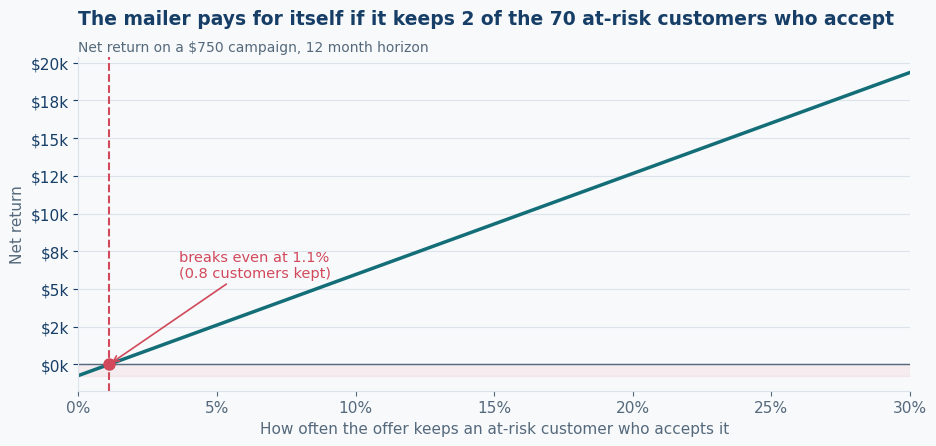

In [17]:
eff = np.linspace(0, 0.30, 61)
net_return = N_MAIL * UPTAKE * PRECISION * eff * value_per_save - cost
breakeven = cost / (N_MAIL * UPTAKE * PRECISION * value_per_save)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.axhspan(net_return.min(), 0, color=coral, alpha=0.07)
ax.plot(eff, net_return, color=teal, lw=2.5)
ax.axhline(0, color=slate, lw=1)
ax.axvline(breakeven, ls="--", color=coral, lw=1.5)
ax.plot([breakeven], [0], "o", color=coral, ms=8, zorder=5)
ax.annotate(f"breaks even at {breakeven:.1%}\n({cost/value_per_save:.1f} customers kept)",
            xy=(breakeven, 0), xytext=(breakeven + 0.025, net_return.max() * 0.30),
            fontsize=10.5, color=coral,
            arrowprops=dict(arrowstyle="->", color=coral, lw=1.2))

ax.set_xlim(0, 0.30)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
ax.yaxis.set_major_formatter(lambda y, pos: f"${y/1000:,.0f}k")
ax.set_xlabel("How often the offer keeps an at-risk customer who accepts it")
ax.set_ylabel("Net return")
ax.grid(axis="x", visible=False)
ax.set_title(f"The mailer pays for itself if it keeps 2 of the {at_risk_takers:.0f} "
             "at-risk customers who accept",
             loc="left", fontsize=13.5, fontweight="bold", pad=24)
ax.text(0, 1.02, f"Net return on a ${cost:,.0f} campaign, {HORIZON} month horizon",
        transform=ax.transAxes, fontsize=10, color=slate)
fig.tight_layout()
fig.savefig("out/mailer_breakeven.png")

> **The campaign costs about $750** and one retained customer is worth around $870, so it
> breaks even on fewer than two customers, roughly 1% of the people who accept the offer.
>
> That holds across every assumption in the grid. At $1.50 a mailer, a six month horizon and
> 60% precision it still only needs 2.3 customers. The decision is not close, so it does not
> need defending at length. The interesting questions are what to put in the mailer, which is
> section 5, and whether it worked, which is section 7.

## 7 · Telling whether it worked

The economics say send it. They do not say the offer works, because nobody has ever tested
it. A holdout fixes that and costs almost nothing:

1. Score everyone and take the **top 600**.
2. **Randomly** assign 500 to the mailer and 100 to receive nothing.
3. Compare churn between the two groups next quarter.

Random assignment is the point. Comparing the 20% who accept against the 80% who ignore the
mailer proves nothing, because people who respond to retention offers were already different.

In [18]:
from scipy.stats import norm

def smallest_detectable_drop(n_treat, n_ctrl, p_ctrl, power=0.80, alpha=0.05):
    """The smallest true churn reduction this design would reliably pick up."""
    za, zb = norm.ppf(1 - alpha / 2), norm.ppf(power)
    for d in np.arange(0.001, 0.60, 0.001):
        p_treat = p_ctrl - d
        if p_treat <= 0:
            break
        pooled = (p_ctrl * n_ctrl + p_treat * n_treat) / (n_treat + n_ctrl)
        se_null = np.sqrt(pooled * (1 - pooled) * (1 / n_treat + 1 / n_ctrl))
        se_alt = np.sqrt(p_ctrl * (1 - p_ctrl) / n_ctrl + p_treat * (1 - p_treat) / n_treat)
        if za * se_null + zb * se_alt <= d:
            return d
    return np.nan

print(f"assuming the control group churns at {PRECISION:.0%}\n")
for n_ctrl in [100, 150, 250, 400]:
    d = smallest_detectable_drop(500, n_ctrl, PRECISION)
    print(f"  control of {n_ctrl:3d}  detects a drop of {d:.1%} or more "
          f"({d/PRECISION:.0%} relative)")

> **Say the limitation out loud.** With 100 held back, the test only picks up a drop of
> about **15 points**. A real but modest effect of 5 points would not show, and reading that
> as failure would be wrong.
>
> | Design | Detects | Cost |
> |---|---|---|
> | 500 mail, 100 control | 15pp or more | free, 100 fewer mailers |
> | 500 mail, 250 control | 10pp or more | needs 750 scored |
> | Repeat over 3 campaigns | 6pp or more | no extra spend, takes 3 quarters |
>
> Recommend the 100 version. It costs nothing and answers the question the retention team
> actually has, which is whether this is worth funding properly.

In [19]:
print("FILES PRODUCED\n")
for f in sorted(Path("out").glob("*")):
    print(f"  {f}  ({f.stat().st_size/1024:.0f} KB)")
print(f"\nBuilt from {SCORES}")
print(f"  mailer list   {len(mailer):,} rows, precision@500 {top['Churn Value'].mean():.1%}")
print(f"  risk list     {len(rest):,} rows")
print(f"  incentive     online security, {gaps.iloc[0]['gap_pp']:.0f}pp gap")
print(f"  campaign      ${cost:,.0f}, breaks even on {cost/value_per_save:.1f} customers")

FILES PRODUCED

  out\addon_gaps.png  (114 KB)
  out\mailer_breakeven.png  (127 KB)
  out\risk_band_distribution.png  (64 KB)
  out\swan_churn_risk_all.csv  (166 KB)
  out\swan_mailer_top500.csv  (35 KB)

Built from churn_scores.csv
  mailer list   500 rows, precision@500 83.4%
  risk list     6,543 rows
  incentive     online security, 27pp gap
  campaign      $750, breaks even on 0.8 customers
